# 03 · Reaction conditions EDA

Deeper exploratory analysis of reaction times and yields: distributions, curated-vs-mined comparisons, and the relationship between reaction time and yield.

In [1]:
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

from ord_analysis.db import get_engine
from ord_analysis import queries

load_dotenv()
engine = get_engine()
sns.set_theme(style="whitegrid")

## Reaction times

`Time` values are stored with heterogeneous units (SECOND/MINUTE/HOUR/DAY); `queries.reaction_times` normalizes them to hours.

In [2]:
times = queries.reaction_times(engine)
print(times.shape)
times["hours"].describe()

(1052378, 4)


count    1.052378e+06
mean     9.320917e+00
std      1.806319e+01
min      0.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      1.600000e+01
max      2.160000e+03
Name: hours, dtype: float64

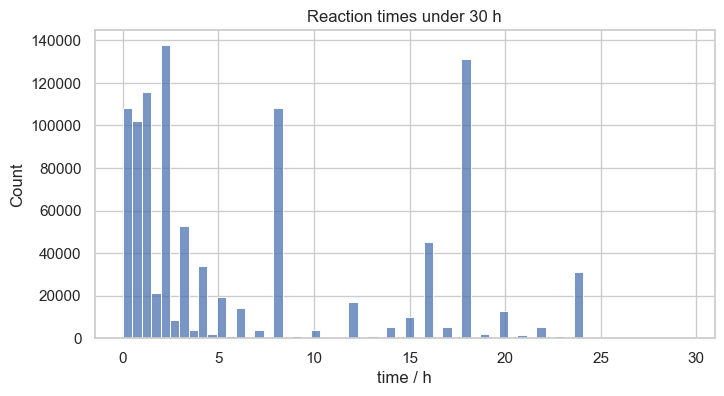

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(times.loc[times["hours"] < 30, "hours"], bins=60, ax=ax)
ax.set_title("Reaction times under 30 h")
ax.set_xlabel("time / h")
plt.show()

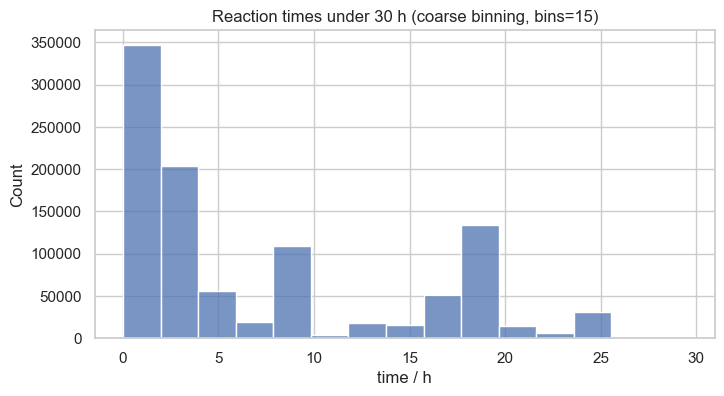

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(times.loc[times["hours"] < 30, "hours"], bins=15, ax=ax)
ax.set_title("Reaction times under 30 h (coarse binning, bins=15)")
ax.set_xlabel("time / h")
plt.show()

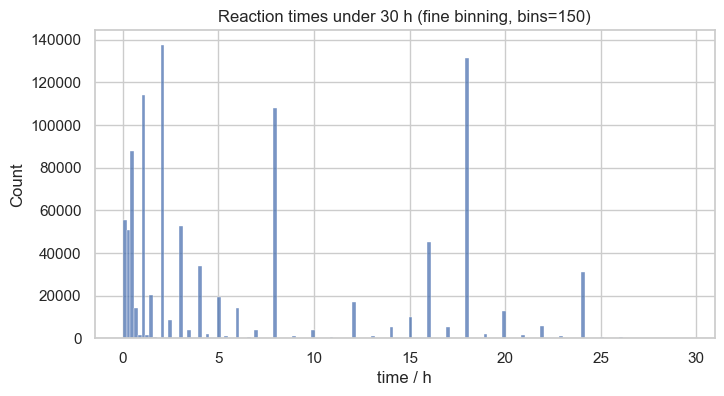

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(times.loc[times["hours"] < 30, "hours"], bins=150, ax=ax)
ax.set_title("Reaction times under 30 h (fine binning, bins=150)")
ax.set_xlabel("time / h")
plt.show()

### Human rounding behaviour

Reaction times are self-reported, so we'd expect scientists to round to "nice" values (whole hours, half hours) rather than reporting arbitrary precision. Two checks: which unit is actually used to record the time, and whether the fractional part of hour-denominated values clusters at round fractions (0, 0.5, 0.25, ...).

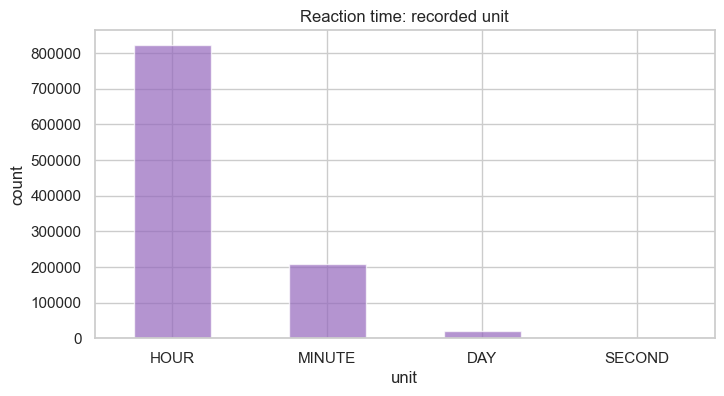

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
times["units"].value_counts().plot.bar(ax=ax, color="tab:purple", alpha=0.7)
ax.set_title("Reaction time: recorded unit")
ax.set_xlabel("unit")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.show()

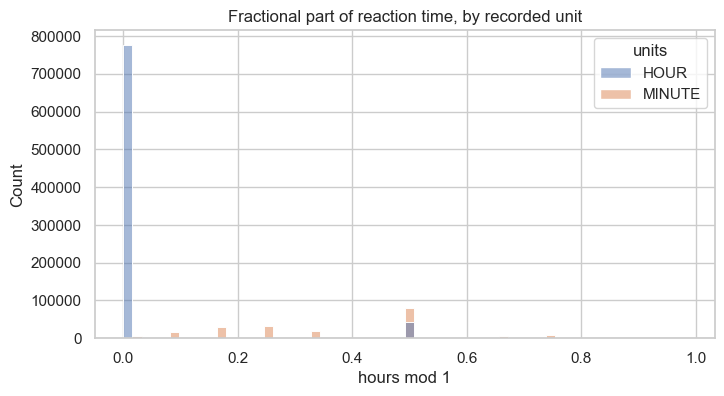

In [7]:
fractional = times[times["units"].isin(["HOUR", "MINUTE"])].copy()
fractional["fractional_hour"] = fractional["hours"] % 1

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=fractional, x="fractional_hour", hue="units", bins=60, multiple="layer", alpha=0.5, ax=ax)
ax.set_title("Fractional part of reaction time, by recorded unit")
ax.set_xlabel("hours mod 1")
plt.show()

## Yields

In [8]:
yields = queries.yields(engine)
print(yields.shape)
yields["value"].describe()

(1601269, 9)


count    1.601269e+06
mean     5.638940e+13
std      7.128521e+16
min     -8.473668e+00
25%      3.710000e+01
50%      6.600000e+01
75%      8.620000e+01
max      9.020516e+19
Name: value, dtype: float64

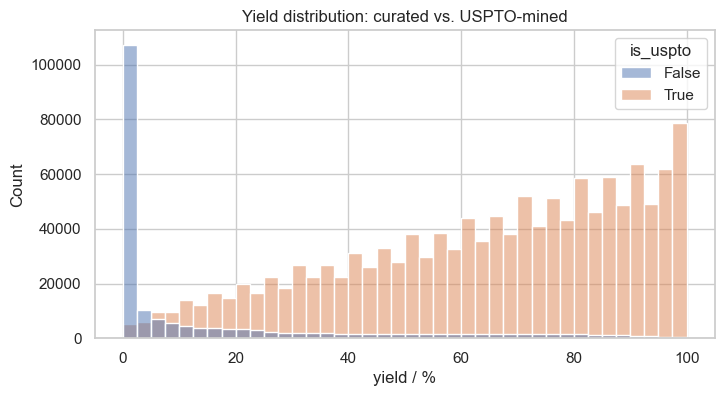

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = yields[(yields["value"] >= 0) & (yields["value"] <= 100)]
sns.histplot(data=plot_data, x="value", hue="is_uspto", bins=40, multiple="layer", alpha=0.5, ax=ax)
ax.set_title("Yield distribution: curated vs. USPTO-mined")
ax.set_xlabel("yield / %")
plt.show()

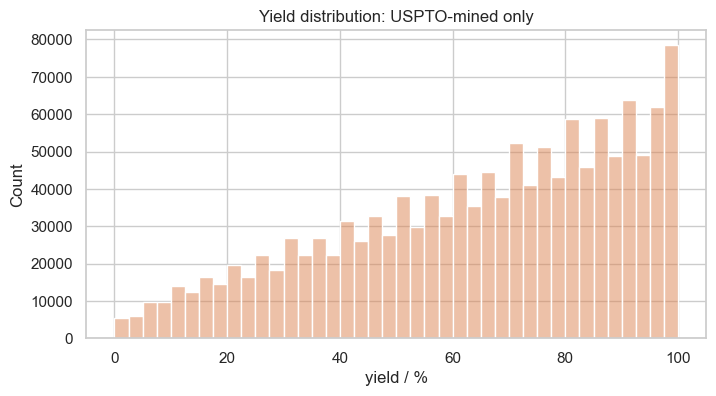

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
uspto_plot_data = plot_data[plot_data["is_uspto"]]
sns.histplot(data=uspto_plot_data, x="value", bins=40, alpha=0.5, ax=ax, color=sns.color_palette()[1])
ax.set_title("Yield distribution: USPTO-mined only")
ax.set_xlabel("yield / %")
plt.show()

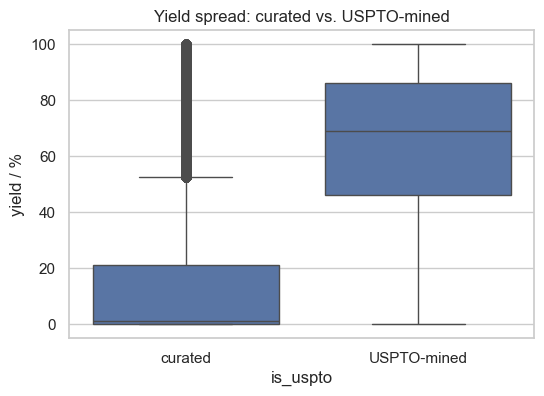

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=plot_data, x="is_uspto", y="value", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["curated", "USPTO-mined"])
ax.set_ylabel("yield / %")
ax.set_title("Yield spread: curated vs. USPTO-mined")
plt.show()

## Reaction time vs. yield

`queries.time_and_yield` pairs the reaction time and yield reported for the *same* `ReactionOutcome`, so we can look at whether they're related.

In [12]:
time_yield = queries.time_and_yield(engine)
print(time_yield.shape)
time_yield.head()

(1016459, 6)


,reaction_id,is_mined,reaction_time_value,reaction_time_units,yield_value,reaction_time_hours
0,ord-5e06ad56a0b94a10b694f08b44eedc69,None,20.000000,HOUR,0.428989,20.000000
1,ord-6b5b2943c1274fbf87d5931a8590ead4,None,14.991976,MINUTE,16.304604,0.249866
2,ord-6b5b2943c1274fbf87d5931a8590ead4,None,14.991976,MINUTE,26.257919,0.249866
3,ord-6b5b2943c1274fbf87d5931a8590ead4,None,14.991976,MINUTE,26.028616,0.249866
4,ord-e637e6e4689643a89ad8194f723f8e0e,None,15.017208,MINUTE,30.279778,0.250287


Pearson correlation (reaction time vs. yield, n=749662): -0.023


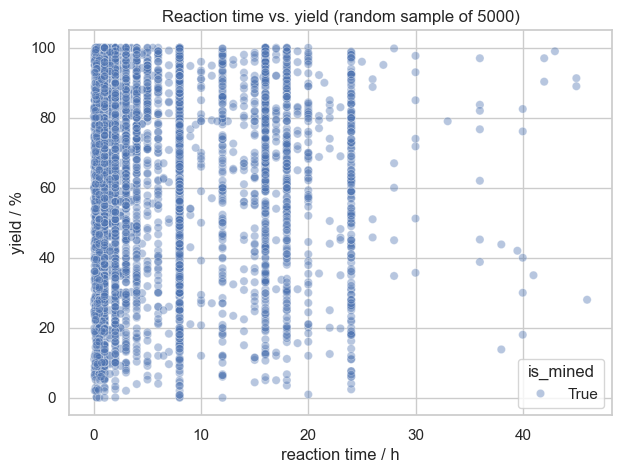

In [13]:
plot_data = time_yield[
    (time_yield["reaction_time_hours"] < 48)
    & (time_yield["yield_value"] >= 0)
    & (time_yield["yield_value"] <= 100)
].dropna(subset=["is_mined"])
corr = plot_data["reaction_time_hours"].corr(plot_data["yield_value"])
print(f"Pearson correlation (reaction time vs. yield, n={len(plot_data)}): {corr:.3f}")

sample = plot_data.sample(n=min(5000, len(plot_data)), random_state=0)
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=sample, x="reaction_time_hours", y="yield_value", hue="is_mined", alpha=0.4, ax=ax)
ax.set_xlabel("reaction time / h")
ax.set_ylabel("yield / %")
ax.set_title(f"Reaction time vs. yield (random sample of {len(sample)})")
plt.show()

## Temperature

`Temperature` values (like `Time`) are stored with heterogeneous units (CELSIUS/FAHRENHEIT/KELVIN); `queries.temperatures` normalizes them to Celsius. This reads `TemperatureConditions.setpoint` -- the target/nominal temperature, not logged measurements.

In [14]:
temps = queries.temperatures(engine)
print(temps.shape)
temps["celsius"].describe()

(905915, 4)


count    905915.000000
mean         48.317025
std         233.711712
min        -264.950000
25%          10.000000
50%          50.000000
75%          80.000000
max      138142.000000
Name: celsius, dtype: float64

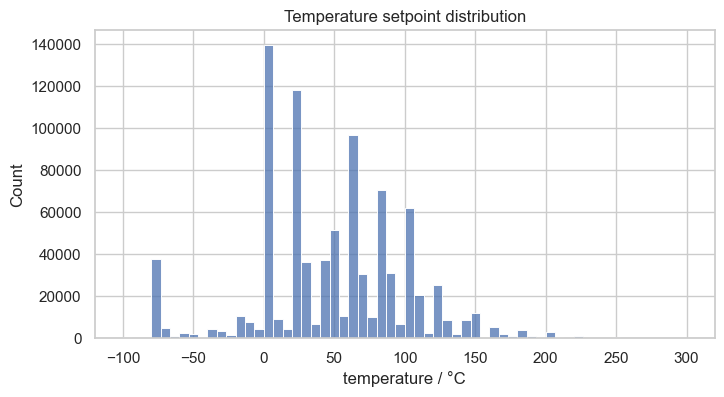

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = temps[(temps["celsius"] >= -100) & (temps["celsius"] <= 300)]
sns.histplot(plot_data["celsius"], bins=60, ax=ax)
ax.set_title("Temperature setpoint distribution")
ax.set_xlabel("temperature / °C")
plt.show()

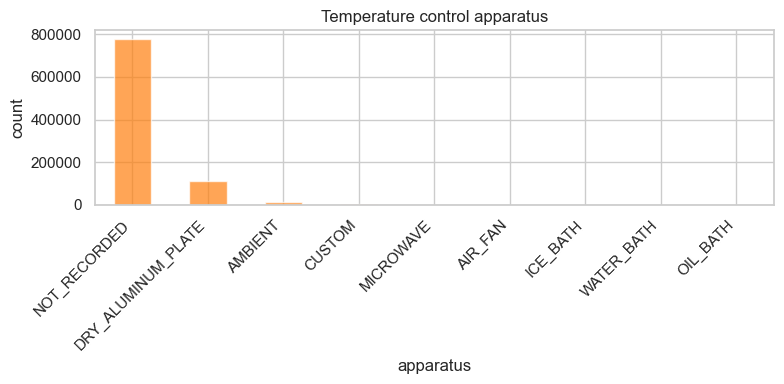

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
temps["control"].value_counts().plot.bar(ax=ax, color="tab:orange", alpha=0.7)
ax.set_title("Temperature control apparatus")
ax.set_xlabel("apparatus")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()